In [30]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

In [2]:
file_path = "../data/green_tripdata_2025-06.parquet"
df = pd.read_parquet(file_path)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-06-01 00:33:43,2025-06-01 01:04:33,N,2.0,74,132,1.0,19.60,70.00,...,0.5,19.61,6.94,NaN,1.0,98.05,1.0,1.0,0.0,0.00
1,2,2025-06-01 00:07:45,2025-06-01 00:14:52,N,1.0,75,74,2.0,1.37,9.30,...,0.5,0.00,0.00,NaN,1.0,11.80,2.0,1.0,0.0,0.00
2,2,2025-06-01 00:24:07,2025-06-01 00:48:24,N,1.0,83,83,1.0,4.11,25.40,...,0.5,0.00,0.00,NaN,1.0,27.90,2.0,1.0,0.0,0.00
3,2,2025-06-01 00:00:14,2025-06-01 00:08:29,N,1.0,97,49,1.0,1.29,9.30,...,0.5,2.36,0.00,NaN,1.0,14.16,1.0,1.0,0.0,0.00
4,2,2025-06-01 00:31:15,2025-06-01 00:43:35,N,1.0,66,25,1.0,1.97,13.50,...,0.5,0.00,0.00,NaN,1.0,16.00,1.0,1.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49385,2,2025-06-30 20:35:00,2025-06-30 20:43:00,None,NaN,152,42,NaN,1.26,13.58,...,0.5,3.02,0.00,NaN,1.0,18.10,NaN,NaN,NaN,0.00
49386,2,2025-06-30 21:35:00,2025-06-30 21:46:00,None,NaN,66,87,NaN,2.20,12.88,...,0.5,3.58,0.00,NaN,1.0,21.46,NaN,NaN,NaN,0.75
49387,2,2025-06-30 22:51:00,2025-06-30 23:14:00,None,NaN,33,164,NaN,6.60,29.51,...,0.5,6.90,0.00,NaN,1.0,41.41,NaN,NaN,NaN,0.75
49388,2,2025-06-30 22:13:00,2025-06-30 22:25:00,None,NaN,42,236,NaN,2.52,18.23,...,0.5,4.50,0.00,NaN,1.0,26.98,NaN,NaN,NaN,0.00


In [3]:
#df = df[df.trip_type == 2]
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-06-01 00:33:43,2025-06-01 01:04:33,N,2.0,74,132,1.0,19.60,70.00,...,0.5,19.61,6.94,NaN,1.0,98.05,1.0,1.0,0.0,0.00
1,2,2025-06-01 00:07:45,2025-06-01 00:14:52,N,1.0,75,74,2.0,1.37,9.30,...,0.5,0.00,0.00,NaN,1.0,11.80,2.0,1.0,0.0,0.00
2,2,2025-06-01 00:24:07,2025-06-01 00:48:24,N,1.0,83,83,1.0,4.11,25.40,...,0.5,0.00,0.00,NaN,1.0,27.90,2.0,1.0,0.0,0.00
3,2,2025-06-01 00:00:14,2025-06-01 00:08:29,N,1.0,97,49,1.0,1.29,9.30,...,0.5,2.36,0.00,NaN,1.0,14.16,1.0,1.0,0.0,0.00
4,2,2025-06-01 00:31:15,2025-06-01 00:43:35,N,1.0,66,25,1.0,1.97,13.50,...,0.5,0.00,0.00,NaN,1.0,16.00,1.0,1.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49385,2,2025-06-30 20:35:00,2025-06-30 20:43:00,None,NaN,152,42,NaN,1.26,13.58,...,0.5,3.02,0.00,NaN,1.0,18.10,NaN,NaN,NaN,0.00
49386,2,2025-06-30 21:35:00,2025-06-30 21:46:00,None,NaN,66,87,NaN,2.20,12.88,...,0.5,3.58,0.00,NaN,1.0,21.46,NaN,NaN,NaN,0.75
49387,2,2025-06-30 22:51:00,2025-06-30 23:14:00,None,NaN,33,164,NaN,6.60,29.51,...,0.5,6.90,0.00,NaN,1.0,41.41,NaN,NaN,NaN,0.75
49388,2,2025-06-30 22:13:00,2025-06-30 22:25:00,None,NaN,42,236,NaN,2.52,18.23,...,0.5,4.50,0.00,NaN,1.0,26.98,NaN,NaN,NaN,0.00


In [4]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
td = df.duration.iloc[0]
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
df.rename(columns={'duration': 'duration_mins'}, inplace=True)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration_mins
0,2,2025-06-01 00:33:43,2025-06-01 01:04:33,N,2.0,74,132,1.0,19.60,70.00,...,19.61,6.94,NaN,1.0,98.05,1.0,1.0,0.0,0.00,30.833333
1,2,2025-06-01 00:07:45,2025-06-01 00:14:52,N,1.0,75,74,2.0,1.37,9.30,...,0.00,0.00,NaN,1.0,11.80,2.0,1.0,0.0,0.00,7.116667
2,2,2025-06-01 00:24:07,2025-06-01 00:48:24,N,1.0,83,83,1.0,4.11,25.40,...,0.00,0.00,NaN,1.0,27.90,2.0,1.0,0.0,0.00,24.283333
3,2,2025-06-01 00:00:14,2025-06-01 00:08:29,N,1.0,97,49,1.0,1.29,9.30,...,2.36,0.00,NaN,1.0,14.16,1.0,1.0,0.0,0.00,8.250000
4,2,2025-06-01 00:31:15,2025-06-01 00:43:35,N,1.0,66,25,1.0,1.97,13.50,...,0.00,0.00,NaN,1.0,16.00,1.0,1.0,0.0,0.00,12.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49385,2,2025-06-30 20:35:00,2025-06-30 20:43:00,None,NaN,152,42,NaN,1.26,13.58,...,3.02,0.00,NaN,1.0,18.10,NaN,NaN,NaN,0.00,8.000000
49386,2,2025-06-30 21:35:00,2025-06-30 21:46:00,None,NaN,66,87,NaN,2.20,12.88,...,3.58,0.00,NaN,1.0,21.46,NaN,NaN,NaN,0.75,11.000000
49387,2,2025-06-30 22:51:00,2025-06-30 23:14:00,None,NaN,33,164,NaN,6.60,29.51,...,6.90,0.00,NaN,1.0,41.41,NaN,NaN,NaN,0.75,23.000000
49388,2,2025-06-30 22:13:00,2025-06-30 22:25:00,None,NaN,42,236,NaN,2.52,18.23,...,4.50,0.00,NaN,1.0,26.98,NaN,NaN,NaN,0.00,12.000000


In [5]:
df = df[(df.duration_mins >= 1) & (df.duration_mins <= 60)]
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration_mins
0,2,2025-06-01 00:33:43,2025-06-01 01:04:33,N,2.0,74,132,1.0,19.60,70.00,...,19.61,6.94,NaN,1.0,98.05,1.0,1.0,0.0,0.00,30.833333
1,2,2025-06-01 00:07:45,2025-06-01 00:14:52,N,1.0,75,74,2.0,1.37,9.30,...,0.00,0.00,NaN,1.0,11.80,2.0,1.0,0.0,0.00,7.116667
2,2,2025-06-01 00:24:07,2025-06-01 00:48:24,N,1.0,83,83,1.0,4.11,25.40,...,0.00,0.00,NaN,1.0,27.90,2.0,1.0,0.0,0.00,24.283333
3,2,2025-06-01 00:00:14,2025-06-01 00:08:29,N,1.0,97,49,1.0,1.29,9.30,...,2.36,0.00,NaN,1.0,14.16,1.0,1.0,0.0,0.00,8.250000
4,2,2025-06-01 00:31:15,2025-06-01 00:43:35,N,1.0,66,25,1.0,1.97,13.50,...,0.00,0.00,NaN,1.0,16.00,1.0,1.0,0.0,0.00,12.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49384,2,2025-06-30 20:11:00,2025-06-30 20:25:00,None,NaN,66,231,NaN,2.18,12.59,...,2.11,0.00,NaN,1.0,19.70,NaN,NaN,NaN,0.75,14.000000
49385,2,2025-06-30 20:35:00,2025-06-30 20:43:00,None,NaN,152,42,NaN,1.26,13.58,...,3.02,0.00,NaN,1.0,18.10,NaN,NaN,NaN,0.00,8.000000
49386,2,2025-06-30 21:35:00,2025-06-30 21:46:00,None,NaN,66,87,NaN,2.20,12.88,...,3.58,0.00,NaN,1.0,21.46,NaN,NaN,NaN,0.75,11.000000
49387,2,2025-06-30 22:51:00,2025-06-30 23:14:00,None,NaN,33,164,NaN,6.60,29.51,...,6.90,0.00,NaN,1.0,41.41,NaN,NaN,NaN,0.75,23.000000


In [6]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [7]:
df[categorical] = df[categorical].astype(str)
df

/tmp/ipykernel_26384/3953903750.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical] = df[categorical].astype(str)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration_mins
0,2,2025-06-01 00:33:43,2025-06-01 01:04:33,N,2.0,74,132,1.0,19.60,70.00,...,19.61,6.94,NaN,1.0,98.05,1.0,1.0,0.0,0.00,30.833333
1,2,2025-06-01 00:07:45,2025-06-01 00:14:52,N,1.0,75,74,2.0,1.37,9.30,...,0.00,0.00,NaN,1.0,11.80,2.0,1.0,0.0,0.00,7.116667
2,2,2025-06-01 00:24:07,2025-06-01 00:48:24,N,1.0,83,83,1.0,4.11,25.40,...,0.00,0.00,NaN,1.0,27.90,2.0,1.0,0.0,0.00,24.283333
3,2,2025-06-01 00:00:14,2025-06-01 00:08:29,N,1.0,97,49,1.0,1.29,9.30,...,2.36,0.00,NaN,1.0,14.16,1.0,1.0,0.0,0.00,8.250000
4,2,2025-06-01 00:31:15,2025-06-01 00:43:35,N,1.0,66,25,1.0,1.97,13.50,...,0.00,0.00,NaN,1.0,16.00,1.0,1.0,0.0,0.00,12.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49384,2,2025-06-30 20:11:00,2025-06-30 20:25:00,None,NaN,66,231,NaN,2.18,12.59,...,2.11,0.00,NaN,1.0,19.70,NaN,NaN,NaN,0.75,14.000000
49385,2,2025-06-30 20:35:00,2025-06-30 20:43:00,None,NaN,152,42,NaN,1.26,13.58,...,3.02,0.00,NaN,1.0,18.10,NaN,NaN,NaN,0.00,8.000000
49386,2,2025-06-30 21:35:00,2025-06-30 21:46:00,None,NaN,66,87,NaN,2.20,12.88,...,3.58,0.00,NaN,1.0,21.46,NaN,NaN,NaN,0.75,11.000000
49387,2,2025-06-30 22:51:00,2025-06-30 23:14:00,None,NaN,33,164,NaN,6.60,29.51,...,6.90,0.00,NaN,1.0,41.41,NaN,NaN,NaN,0.75,23.000000


In [11]:
train_dicts = df[categorical + numerical].to_dict(orient='records')
train_dicts

[{'PULocationID': '74', 'DOLocationID': '132', 'trip_distance': 19.6},
 {'PULocationID': '75', 'DOLocationID': '74', 'trip_distance': 1.37},
 {'PULocationID': '83', 'DOLocationID': '83', 'trip_distance': 4.11},
 {'PULocationID': '97', 'DOLocationID': '49', 'trip_distance': 1.29},
 {'PULocationID': '66', 'DOLocationID': '25', 'trip_distance': 1.97},
 {'PULocationID': '130', 'DOLocationID': '205', 'trip_distance': 2.32},
 {'PULocationID': '255', 'DOLocationID': '49', 'trip_distance': 3.4},
 {'PULocationID': '37', 'DOLocationID': '41', 'trip_distance': 0.0},
 {'PULocationID': '244', 'DOLocationID': '244', 'trip_distance': 0.06},
 {'PULocationID': '41', 'DOLocationID': '42', 'trip_distance': 1.43},
 {'PULocationID': '75', 'DOLocationID': '74', 'trip_distance': 1.44},
 {'PULocationID': '95', 'DOLocationID': '160', 'trip_distance': 2.36},
 {'PULocationID': '255', 'DOLocationID': '80', 'trip_distance': 1.69},
 {'PULocationID': '260', 'DOLocationID': '7', 'trip_distance': 1.83},
 {'PULocationI

In [12]:
dv = DictVectorizer()
x_train = dv.fit_transform(train_dicts)
x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 138462 stored elements and shape (46154, 472)>

In [13]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=11',
 'DOLocationID=111',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',
 'DOLocationID=146',
 'DOLocationID=147',

In [15]:
target = 'duration_mins'
y_train = df[target].values
y_train

array([30.83333333,  7.11666667, 24.28333333, ..., 11.        ,
       23.        , 12.        ], shape=(46154,))

In [18]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
y_pred = lr.predict(x_train)
y_pred

array([36.03594689,  7.39946957, 10.87167297, ..., 24.12697364,
       26.60819512, 11.93707176], shape=(46154,))

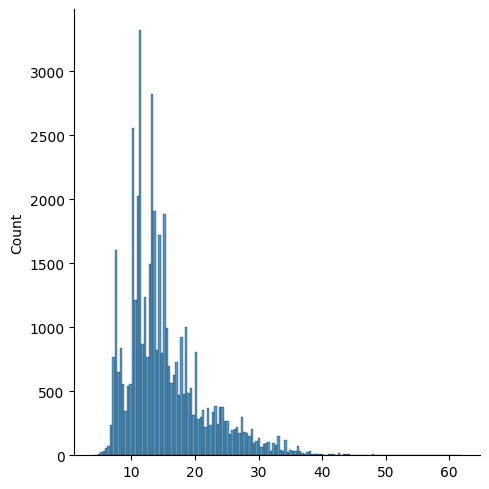

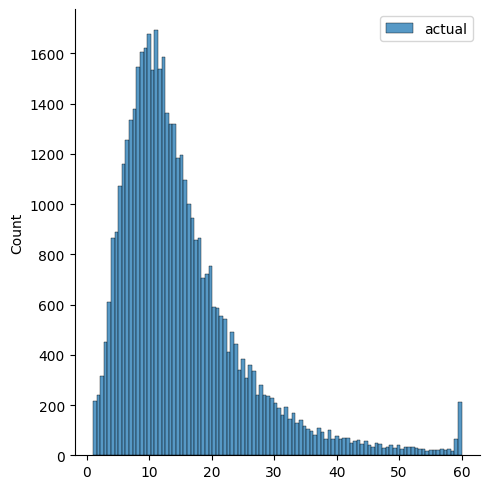

In [23]:
sb.displot(y_pred, label='prediction')
sb.displot(y_train, label='actual')
plt.legend()

In [29]:
mean_squared_error(y_train, y_pred)

59.257700253420275